In [1]:
import pandas as pd
import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
df = pd.read_csv("../dataset/cleaned/clean_house_price_india.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

Dataset Loaded Successfully!
Shape: (13859, 24)


In [3]:
df.columns.tolist()

['id',
 'date',
 'number_of_bedrooms',
 'number_of_bathrooms',
 'living_area',
 'lot_area',
 'number_of_floors',
 'waterfront_present',
 'number_of_views',
 'condition_of_the_house',
 'grade_of_the_house',
 'area_of_the_house(excluding_basement)',
 'area_of_the_basement',
 'built_year',
 'renovation_year',
 'postal_code',
 'lattitude',
 'longitude',
 'living_area_renov',
 'lot_area_renov',
 'number_of_schools_nearby',
 'distance_from_the_airport',
 'price',
 'property_age']

In [4]:
df = df.rename(columns={
    "area_of_the_house(excluding_basement)": "house_area_without_basement"
})

print("Column renamed successfully!")

Column renamed successfully!


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13859 entries, 0 to 13858
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           13859 non-null  int64  
 1   date                         13859 non-null  int64  
 2   number_of_bedrooms           13859 non-null  int64  
 3   number_of_bathrooms          13859 non-null  float64
 4   living_area                  13859 non-null  int64  
 5   lot_area                     13859 non-null  int64  
 6   number_of_floors             13859 non-null  float64
 7   waterfront_present           13859 non-null  int64  
 8   number_of_views              13859 non-null  int64  
 9   condition_of_the_house       13859 non-null  int64  
 10  grade_of_the_house           13859 non-null  int64  
 11  house_area_without_basement  13859 non-null  int64  
 12  area_of_the_basement         13859 non-null  int64  
 13  built_year                 

In [6]:
df.isnull().sum()

id                             0
date                           0
number_of_bedrooms             0
number_of_bathrooms            0
living_area                    0
lot_area                       0
number_of_floors               0
waterfront_present             0
number_of_views                0
condition_of_the_house         0
grade_of_the_house             0
house_area_without_basement    0
area_of_the_basement           0
built_year                     0
renovation_year                0
postal_code                    0
lattitude                      0
longitude                      0
living_area_renov              0
lot_area_renov                 0
number_of_schools_nearby       0
distance_from_the_airport      0
price                          0
property_age                   0
dtype: int64

In [7]:
numerical_columns = df.select_dtypes(
    include=['int64','float64']
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=['object']
).columns.tolist()


print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['id', 'date', 'number_of_bedrooms', 'number_of_bathrooms', 'living_area', 'lot_area', 'number_of_floors', 'waterfront_present', 'number_of_views', 'condition_of_the_house', 'grade_of_the_house', 'house_area_without_basement', 'area_of_the_basement', 'built_year', 'renovation_year', 'postal_code', 'lattitude', 'longitude', 'living_area_renov', 'lot_area_renov', 'number_of_schools_nearby', 'distance_from_the_airport', 'price', 'property_age']

Categorical Columns:
[]


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
features = df.drop(
    columns=[
        "id",
        "date",
        "price"
    ]
)

target = df["price"]


print("Features Shape:", features.shape)
print("Target Shape:", target.shape)

Features Shape: (13859, 21)
Target Shape: (13859,)


In [10]:
correlation = df.corr()["price"].sort_values(
    ascending=False
)

correlation

price                          1.000000
grade_of_the_house             0.647629
living_area                    0.638922
living_area_renov              0.577698
house_area_without_basement    0.546075
number_of_bathrooms            0.466374
lattitude                      0.422816
number_of_bedrooms             0.298872
number_of_floors               0.279132
number_of_views                0.241718
area_of_the_basement           0.237322
lot_area                       0.096008
renovation_year                0.091372
lot_area_renov                 0.080134
longitude                      0.080069
built_year                     0.066145
waterfront_present             0.053646
condition_of_the_house         0.044879
distance_from_the_airport      0.007484
number_of_schools_nearby       0.004843
date                          -0.042921
property_age                  -0.066145
postal_code                   -0.291916
id                            -0.964835
Name: price, dtype: float64

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)


scaled_features = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_features.head()

,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,grade_of_the_house,house_area_without_basement,...,built_year,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,property_age
0,0.718714,0.610046,1.687492,0.746264,0.959757,-0.057075,-0.268014,-0.646877,1.383370,2.164078,...,1.032690,-0.205387,-1.466558,1.165654,0.575773,2.269381,1.169110,1.210768,1.236614,-1.032690
1,-0.366916,-0.094125,0.918413,-0.271116,0.029728,-0.057075,-0.268014,0.867493,0.423804,0.215045,...,-1.428099,-0.205387,-1.414054,0.819290,-0.571474,0.202462,-0.308117,-1.238336,-1.563202,1.428099
2,-0.366916,0.610046,0.777415,-0.264509,-0.900300,-0.057075,-0.268014,0.867493,1.383370,-0.030288,...,-0.676191,-0.205387,-1.361550,0.880708,-1.305992,0.715186,-0.298486,-1.238336,0.228680,0.676191
3,1.804345,1.666302,2.136121,-0.073047,0.959757,-0.057075,2.840277,-0.646877,2.342936,2.641113,...,1.203578,-0.205387,-1.309045,-0.187665,2.471528,2.221313,-0.048436,1.210768,0.788643,-1.203578
4,-0.366916,-0.446210,0.315967,-0.110494,0.959757,-0.057075,-0.268014,2.381862,0.423804,-0.234732,...,-1.633165,-0.205387,-1.414054,0.967120,-0.550488,-0.582647,-0.073976,1.210768,0.676651,1.633165


In [12]:
# Combine scaled features with target

processed_df = scaled_features.copy()

processed_df["price"] = target.values

print("Processed Dataset Shape:", processed_df.shape)

processed_df.head()

Processed Dataset Shape: (13859, 22)


,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,grade_of_the_house,house_area_without_basement,...,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,property_age,price
0,0.718714,0.610046,1.687492,0.746264,0.959757,-0.057075,-0.268014,-0.646877,1.383370,2.164078,...,-0.205387,-1.466558,1.165654,0.575773,2.269381,1.169110,1.210768,1.236614,-1.032690,838000
1,-0.366916,-0.094125,0.918413,-0.271116,0.029728,-0.057075,-0.268014,0.867493,0.423804,0.215045,...,-0.205387,-1.414054,0.819290,-0.571474,0.202462,-0.308117,-1.238336,-1.563202,1.428099,805000
2,-0.366916,0.610046,0.777415,-0.264509,-0.900300,-0.057075,-0.268014,0.867493,1.383370,-0.030288,...,-0.205387,-1.361550,0.880708,-1.305992,0.715186,-0.298486,-1.238336,0.228680,0.676191,790000
3,1.804345,1.666302,2.136121,-0.073047,0.959757,-0.057075,2.840277,-0.646877,2.342936,2.641113,...,-0.205387,-1.309045,-0.187665,2.471528,2.221313,-0.048436,1.210768,0.788643,-1.203578,785000
4,-0.366916,-0.446210,0.315967,-0.110494,0.959757,-0.057075,-0.268014,2.381862,0.423804,-0.234732,...,-0.205387,-1.414054,0.967120,-0.550488,-0.582647,-0.073976,1.210768,0.676651,1.633165,750000


In [13]:
from sklearn.model_selection import train_test_split

X = processed_df.drop(
    columns=["price"]
)

y = processed_df["price"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (11087, 21)
Testing Data: (2772, 21)


In [14]:
import os

os.makedirs(
    "../dataset/processed",
    exist_ok=True
)


processed_df.to_csv(
    "../dataset/processed/realestate_features.csv",
    index=False
)


print("Feature dataset saved successfully!")

Feature dataset saved successfully!


In [15]:
!pip install xgboost catboost lightgbm


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


import numpy as np
import pandas as pd

In [17]:
models = {

"Linear Regression":
LinearRegression(),

"Random Forest":
RandomForestRegressor(
    n_estimators=200,
    random_state=42
),

"Gradient Boosting":
GradientBoostingRegressor(
    random_state=42
),

"XGBoost":
XGBRegressor(
    n_estimators=200,
    random_state=42
),

"CatBoost":
CatBoostRegressor(
    iterations=200,
    verbose=0,
    random_state=42
),

"LightGBM":
LGBMRegressor(
    n_estimators=200,
    random_state=42
)

}

In [18]:
# ---------------- MODEL TRAINING & COMPARISON ----------------

results = []

for name, model in models.items():

    print(f"Training {name} ...")

    model.fit(
        X_train,
        y_train
    )


    predictions = model.predict(
        X_test
    )


    mae = mean_absolute_error(
        y_test,
        predictions
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )


    r2 = r2_score(
        y_test,
        predictions
    )


    results.append(
        [
            name,
            mae,
            rmse,
            r2
        ]
    )


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)


results_df

Training Linear Regression ...
Training Random Forest ...
Training Gradient Boosting ...
Training XGBoost ...
Training CatBoost ...
Training LightGBM ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2417
[LightGBM] [Info] Number of data points in the train set: 11087, number of used features: 21
[LightGBM] [Info] Start training from score 476653.052404


,Model,MAE,RMSE,R2 Score
0,Linear Regression,83722.832347,111651.831992,0.715984
1,Random Forest,50769.668604,73533.195897,0.876809
2,Gradient Boosting,56818.858493,80106.425153,0.853800
3,XGBoost,51019.023438,71935.519571,0.882104
4,CatBoost,49284.947442,70103.412863,0.888033
5,LightGBM,48136.157182,69263.912138,0.890699


In [19]:
# ---------------- BEST MODEL ----------------


best_model_name = (
    results_df
    .sort_values(
        "R2 Score",
        ascending=False
    )
    .iloc[0]["Model"]
)


print(
    "Best Model:",
    best_model_name
)

Best Model: LightGBM


In [20]:
import joblib


best_model = models[best_model_name]


joblib.dump(
    best_model,
    "../models/best_house_price_model.pkl"
)


print(
    "Best model saved successfully!"
)

Best model saved successfully!


In [21]:
results_df.to_csv(
    "../models/model_comparison.csv",
    index=False
)


print(
    "Comparison saved!"
)

Comparison saved!


In [22]:
# ---------------- MODEL COMPARISON ----------------

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,LightGBM,48136.157182,69263.912138,0.890699
1,CatBoost,49284.947442,70103.412863,0.888033
2,XGBoost,51019.023438,71935.519571,0.882104
3,Random Forest,50769.668604,73533.195897,0.876809
4,Gradient Boosting,56818.858493,80106.425153,0.853800
5,Linear Regression,83722.832347,111651.831992,0.715984


In [23]:
# ---------------- SAVE MODEL COMPARISON ----------------

results_df.to_csv(
    "../models/model_comparison.csv",
    index=False
)

print("Model comparison report saved successfully!")

Model comparison report saved successfully!


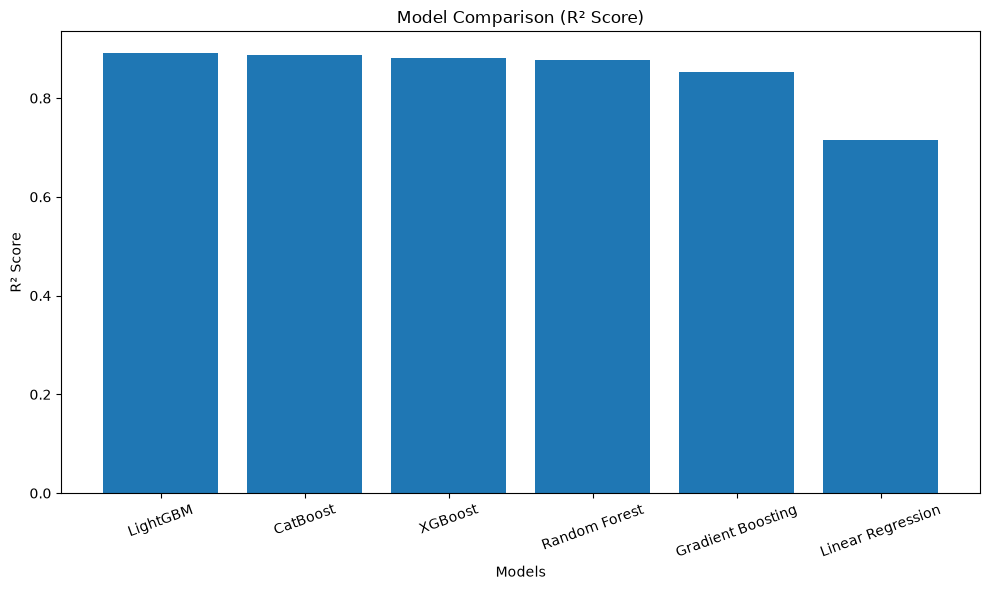

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [25]:
best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

import joblib

joblib.dump(
    best_model,
    "../models/best_house_price_model.pkl"
)

print(f"Best model saved: {best_model_name}")

Best model saved: LightGBM


In [26]:
!pip install shap


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import shap
import matplotlib.pyplot as plt

print("SHAP imported successfully!")

SHAP imported successfully!


In [28]:
# Use the best trained model
model = best_model

print(type(model))

<class 'lightgbm.sklearn.LGBMRegressor'>


In [29]:
# Create SHAP explainer

explainer = shap.Explainer(
    model,
    X_train
)

print("Explainer created successfully!")

Background dataset has 11087 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=11087 when initializing the masker.


Explainer created successfully!


In [30]:
# Calculate SHAP values

shap_values = explainer(X_test)

print("SHAP values calculated!")

 99%|===================| 2737/2772 [00:23<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 410942.789325, while the model output was 421660.351948. If this difference is acceptable you can set check_additivity=False to disable this check.

In [31]:
shap_values = explainer(
    X_test,
    check_additivity=False
)

print("SHAP values calculated successfully!")

 99%|===================| 2746/2772 [00:23<00:00]        

SHAP values calculated successfully!


In [32]:
import shap

# Create SHAP Tree Explainer
explainer = shap.TreeExplainer(best_model)

print("SHAP Tree Explainer created successfully!")

SHAP Tree Explainer created successfully!


In [33]:
# Calculate SHAP values

shap_values = explainer.shap_values(
    X_test,
    check_additivity=False
)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


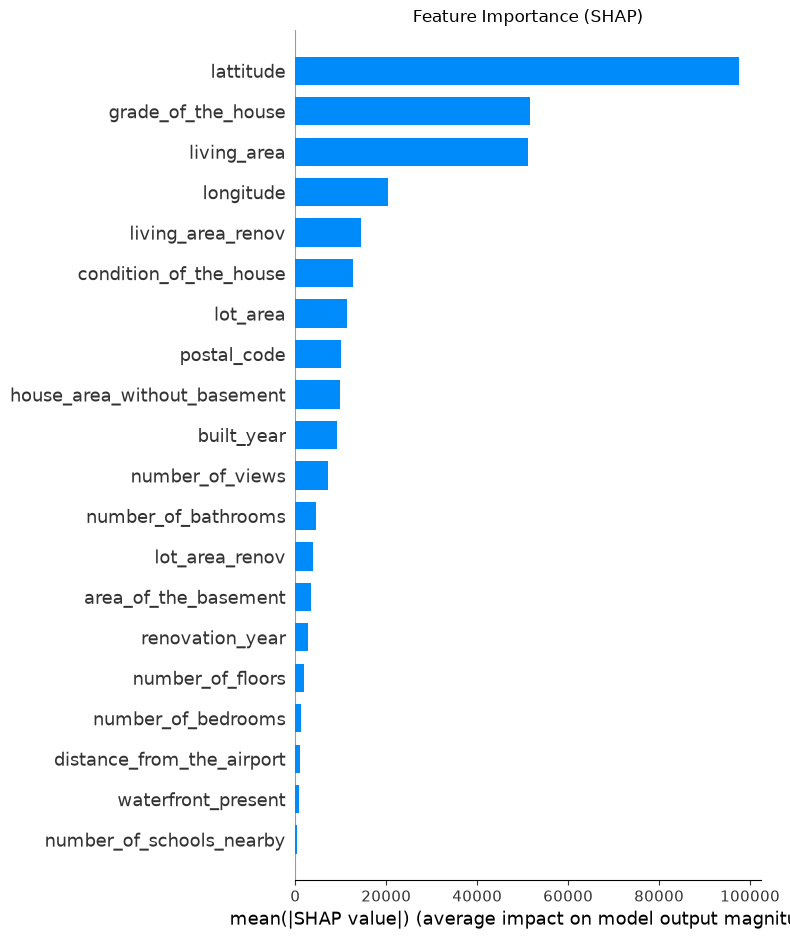

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

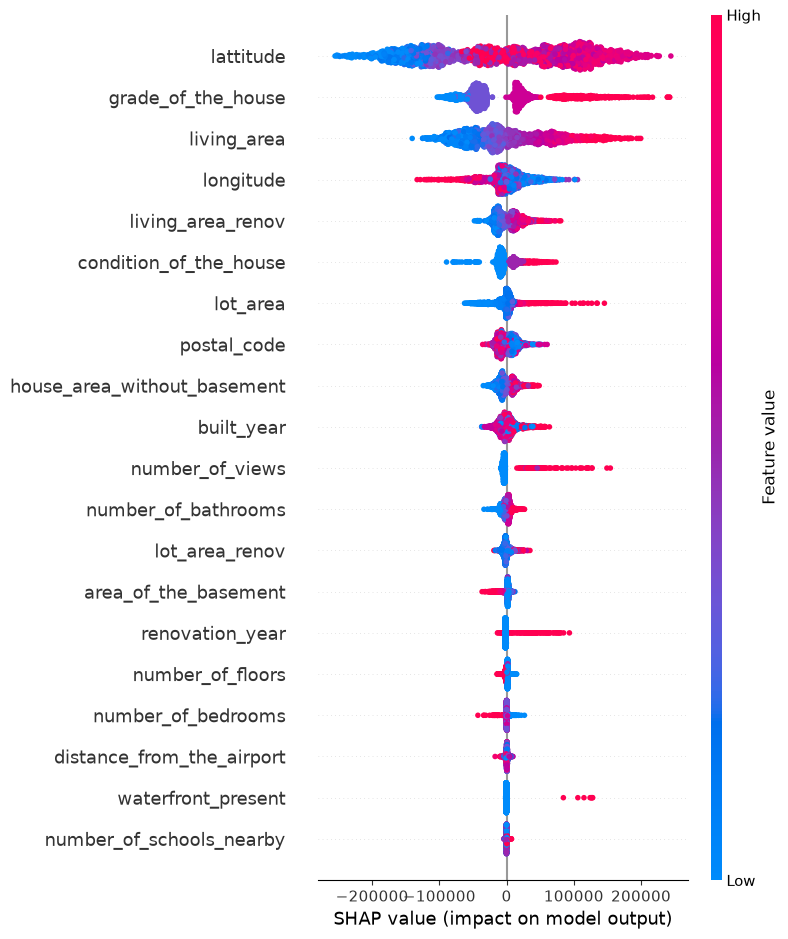

In [35]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test
)

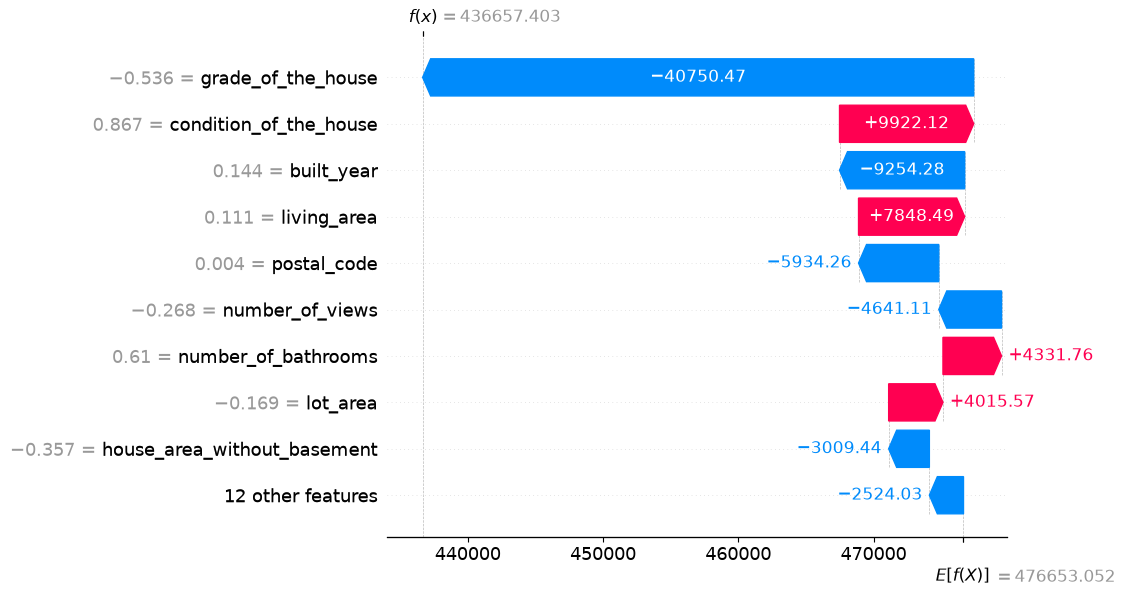

In [36]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)